In [16]:
# =========================================================
# 1. Imports & Config
# =========================================================
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print("Device:", DEVICE)

Device: mps


In [17]:
# =========================================================
# 2. Dataset Class
# =========================================================
class SimpleDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.float()
        self.y = y.float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [18]:
# =========================================================
# 3. Regression Dataset
# =========================================================
n_samples = 500
X_reg = torch.randn(n_samples, 3) * 3

y_reg = (2 * X_reg[:, 0].unsqueeze(1) +
         3 * X_reg[:, 1].unsqueeze(1) +
         0.1 * (X_reg[:, 0] * X_reg[:, 1]).unsqueeze(1) +
         5 * X_reg[:, 2].unsqueeze(1))

noise = torch.randn(n_samples, 1) * 5
y_reg += noise

outlier_indices = torch.randperm(len(y_reg))[:int(0.05 * len(y_reg))]
y_reg[outlier_indices] += torch.randn(len(outlier_indices), 1) * 20

train_size = int(0.8 * len(X_reg))
X_train_reg, X_test_reg = X_reg[:train_size], X_reg[train_size:]
y_train_reg, y_test_reg = y_reg[:train_size], y_reg[train_size:]

train_loader_reg = DataLoader(SimpleDataset(X_train_reg, y_train_reg), batch_size=32, shuffle=True)
test_loader_reg = DataLoader(SimpleDataset(X_test_reg, y_test_reg), batch_size=32)

In [19]:
# =========================================================
# 4. Linear Regression Model
# =========================================================
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(3, 1)

    def forward(self, x):
        return self.linear(x)


model_reg = LinearRegression().to(DEVICE)
criterion_reg = nn.MSELoss()
optimizer_reg = optim.SGD(model_reg.parameters(), lr=0.05, momentum=0.9)

In [20]:
# =========================================================
# 5. Training Regression
# =========================================================
train_losses_reg, test_losses_reg = [], []

for epoch in range(100):
    model_reg.train()
    train_loss = 0

    for X_batch, y_batch in train_loader_reg:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        preds = model_reg(X_batch)
        loss = criterion_reg(preds, y_batch)

        optimizer_reg.zero_grad()
        loss.backward()
        optimizer_reg.step()

        train_loss += loss.item()

    train_loss /= len(train_loader_reg)
    train_losses_reg.append(train_loss)

    model_reg.eval()
    test_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_reg:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            preds = model_reg(X_batch)
            loss = criterion_reg(preds, y_batch)
            test_loss += loss.item()

    test_loss /= len(test_loader_reg)
    test_losses_reg.append(test_loss)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

Epoch 50 | Train Loss: 81.1768 | Test Loss: 45.0589
Epoch 100 | Train Loss: 155.5209 | Test Loss: 91.5217


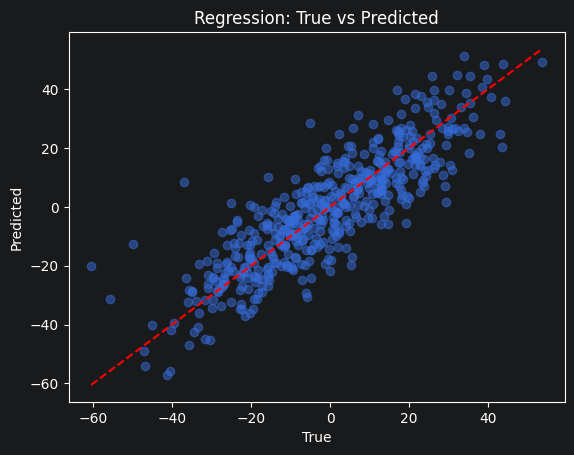

In [21]:
# =========================================================
# 6. Regression Visualization
# =========================================================
model_reg.eval()
with torch.no_grad():
    preds = model_reg(X_reg.to(DEVICE)).cpu()

plt.scatter(y_reg.numpy(), preds.numpy(), alpha=0.5)
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'r--')
plt.title("Regression: True vs Predicted")
plt.xlabel("True")
plt.ylabel("Predicted")
plt.show()

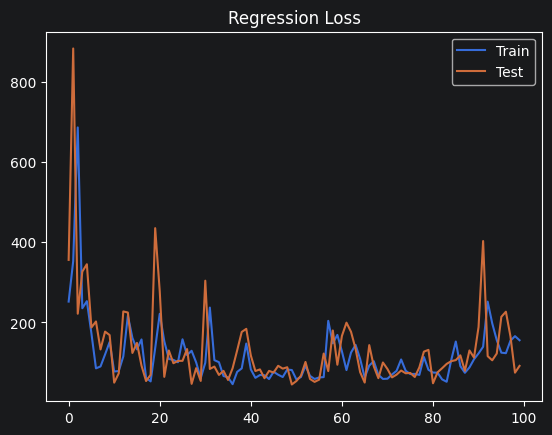

In [22]:
# =========================================================
# 7. Regression Loss Curve
# =========================================================
plt.plot(train_losses_reg, label="Train")
plt.plot(test_losses_reg, label="Test")
plt.legend()
plt.title("Regression Loss")
plt.show()

In [23]:
# =========================================================
# 8. Classification Dataset
# =========================================================
X0 = torch.randn(200, 4) * 0.5 + torch.tensor([-1.0, -1.0, 0.5, -0.5])
X1 = torch.randn(200, 4) * 0.5 + torch.tensor([1.0, 1.0, -0.5, 0.5])

X_clf = torch.cat([X0, X1], dim=0)
y_clf = torch.cat([torch.zeros(200, 1), torch.ones(200, 1)], dim=0)

perm = torch.randperm(len(X_clf))
X_clf, y_clf = X_clf[perm], y_clf[perm]

train_size = int(0.8 * len(X_clf))
X_train_clf, X_test_clf = X_clf[:train_size], X_clf[train_size:]
y_train_clf, y_test_clf = y_clf[:train_size], y_clf[train_size:]

train_loader_clf = DataLoader(SimpleDataset(X_train_clf, y_train_clf), batch_size=32, shuffle=True)
test_loader_clf = DataLoader(SimpleDataset(X_test_clf, y_test_clf), batch_size=32)

In [24]:
# =========================================================
# 9. Logistic Regression Model
# =========================================================
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))


model_clf = LogisticRegression().to(DEVICE)
criterion_clf = nn.BCELoss()
optimizer_clf = optim.Adam(model_clf.parameters(), lr=0.01)

In [25]:
# =========================================================
# 10. Training Classification
# =========================================================
train_losses_clf, test_accs = [], []

for epoch in range(100):
    model_clf.train()
    total_loss = 0

    for X_batch, y_batch in train_loader_clf:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)

        outputs = model_clf(X_batch)
        loss = criterion_clf(outputs, y_batch)

        optimizer_clf.zero_grad()
        loss.backward()
        optimizer_clf.step()

        total_loss += loss.item()

    total_loss /= len(train_loader_clf)
    train_losses_clf.append(total_loss)

    model_clf.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_clf:
            outputs = model_clf(X_batch.to(DEVICE))
            preds = (outputs > 0.5).float()

            correct += (preds == y_batch.to(DEVICE)).sum().item()
            total += y_batch.size(0)

    acc = correct / total
    test_accs.append(acc)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch + 1} | Loss: {total_loss:.4f} | Accuracy: {acc:.4f}")

Epoch 50 | Loss: 0.0176 | Accuracy: 1.0000
Epoch 100 | Loss: 0.0093 | Accuracy: 1.0000


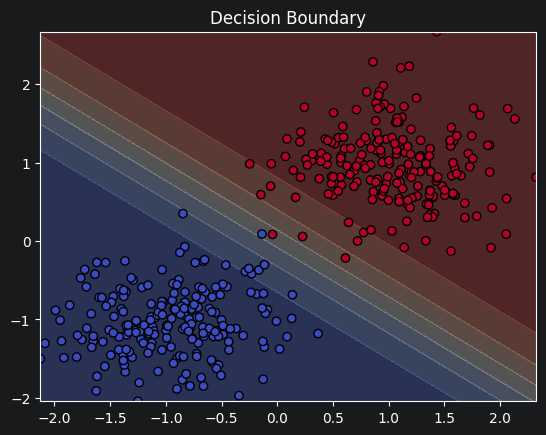

In [26]:
# =========================================================
# 11. Decision Boundary
# =========================================================
X_vis = X_clf[:, :2]

xx, yy = np.meshgrid(
    np.linspace(X_vis[:, 0].min(), X_vis[:, 0].max(), 200),
    np.linspace(X_vis[:, 1].min(), X_vis[:, 1].max(), 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid4 = np.zeros((grid.shape[0], 4))
grid4[:, :2] = grid

with torch.no_grad():
    Z = model_clf(torch.tensor(grid4).float().to(DEVICE)).cpu().numpy()

Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y_clf.squeeze(), cmap='coolwarm', edgecolors='k')
plt.title("Decision Boundary")
plt.show()

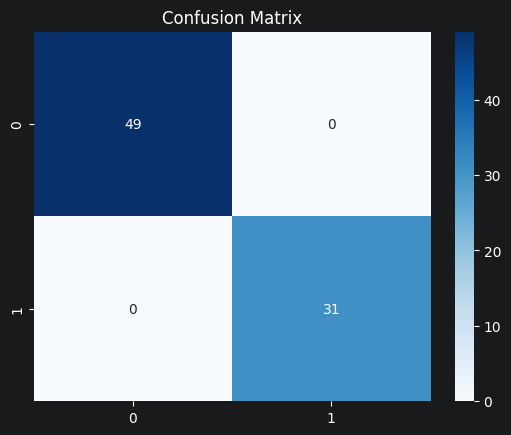

In [27]:
# =========================================================
# 12. Confusion Matrix
# =========================================================
with torch.no_grad():
    preds = model_clf(X_test_clf.to(DEVICE)).cpu()
    preds_class = (preds > 0.5).int()

cm = confusion_matrix(y_test_clf.numpy(), preds_class.numpy())

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()